---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<br><br>
<h1 align="center">Lec-18: A Quick Recap of Deep Neural Networks</h1>

# Learning agenda of this notebook
1. Recap of Deep Learning Architectures
2. Recap: Artificial Neural Network (mlp)
3. How Pre-Training of LLMs is Done?
4. Coding Examples for ANN
5. Example Questions to Check your Understanding about Training of a Feed Forward Neural Network

# <span style='background :lightgreen' >1. Recap of Deep Learning Architectures</span>
<div style="text-align:center;">
    <img src="../images/deep-learning-recap.png"
         style="max-width:2000px; width:100%; height:auto; display:inline-block;">
</div>

<h2 align="center"><div class="alert alert-success" style="margin: 20px">ANNs, CNNs, and RNNs serve as foundational building blocks, while architectures such as Variational Autoencoders (VAEs), Generative Adversarial Networks (GANs), Diffusion Models, and Transformers leverage these components to accomplish specific tasks and objectives. </h2>

<h2 align="center"><div class="alert alert-success" style="margin: 20px"><b>ANN:</b> Looks at a single snapshot and makes a decision (no context, no spatial awareness)</h2>

- **ANN (Artificial Neural Network):**
    - The most basic form: fully connected layers (also called Dense or Multi-Layer Perceptron)
    - Every neuron in one layer connects to every neuron in the next layer.
    - Treats every input independently in sequence one after another. Has no memory of previous inputs, so the NW forgets previous words. This makes it unsuitable for language modeling (NLU, NLG) and sequence prediction.
    - Good for: Simple data, tabular data, basic classification
    
<h2 align="center"><div class="alert alert-success" style="margin: 20px"><b>CNN:</b> Examines an image region by region, building understanding from local to global (spatial awareness)</h2>

- **CNN (Convolutional Neural Network):**
    - Specialized for spatial patterns (images, videos)
    - Uses convolution operations to detect features like edges, textures, shapes
    - Key advantage: Processes nearby pixels together, understanding local patterns
  
<h2 align="center"><div class="alert alert-success" style="margin: 20px"><b>RNN:</b> Reads a story word by word, remembering what came before (temporal awareness)</h2>

- **RNN (Recurrent Neural Network):**
    - Specialized for sequential/temporal patterns (text, speech, time series)
    - Has memory—can remember previous information in a sequence (LSTM and GRU are variants of RNNs)
    - Works for small sentences like: "The capital of Pakistan is ...."
    - Donot work for long sentences like "Pakistan is a beautiful city with high mountain peaks, an ocean and deserts with a population of over 26 crore and its capital is ....". This is because of vanishing/exploding gradient problem, because during backpropagation gradient shrink and earlier information gets lost
    - Key advantage: Understands order and context over time

## Generative Architectures
- **Variational Autoencoder (VAE, 2013):** Compresses data into a latent space and reconstructs it. Its building blocks are:
    - For images: VAE uses a CNN-based encoder (convolutional layers to downsample) and a CNN-based decoder (transposed convolutions to upsample)
    - For sequences (text, music): VAE incorporates RNNs in both the encoder and decoder to handle sequential dependencies, producing latent variables that capture temporal structure
    - For tabular data: Uses standard ANN (fully connected layers)
- **Generative Adversarial Network (GAN, 2014):** Generate realistic data samples (commonly images, but also audio, video, tabular) using two competing networks. The Generator creates fake data and the Discriminator classifies whether it is real or fake. Its building  blocks are:
    - Generator: Typically uses transposed CNNs for image generation; can use RNNs for sequential data
    - Discriminator: Acts as a binary classifier — usually CNN-based for images
- **Diffusion Models (2015, popularized in 2020):** Gradually add noise to data during a forward process, then train a model to reverse this process (denoise) to generate new samples. Its building blocks are:
    - Typically built on U-Net style architectures (CNN-based), but these days they are enhanced with attention or Transformer blocks.
    - Encoder path → CNN layers with downsampling to compress
    - Decoder path → CNN layers with upsampling to reconstruct
    - Skip connections → Preserve spatial details across encoder and decoder
    - Timestep embeddings → Inform the model of the current noise level
    - In latent diffusion models like Stable Diffusion, a VAE compresses the image into latent space first, and cross-attention layers condition generation on text
- **Transformer Architecture (2017):** Designed for sequence understanding and generation without recurrence, using a self-attention mechanism instead. The key advantage is efficient capture of long-range relationships. Comes in three variants:
    - Encoder-only (e.g., BERT): For understanding tasks like classification
    - Decoder-only (e.g., GPT): Generates text by predicting the next token
    - Encoder-Decoder (e.g., T5, original Transformer): For tasks like translation and summarization
    - Built using feed-forward layers, positional encoding, and Multi-Head Attention.

# <span style='background :lightgreen' >2. Recap: Artificial Neural Network (mlp)</span>

<div style="text-align:center;">
    <img src="../images/llm-learning3.png"
         style="max-width:1700px; width:100%; height:auto; display:inline-block;">
</div>

>- **Vanishing Gradient Problem:** During backpropagation, gradients are multiplied together as they travel backwards through each layer. If these multiplied values are small numbers (less than 1), the gradient shrinks with every layer it passes through, becoming so tiny by the time it reaches the early layers that those weights receive virtually zero update and completely stop learning. This is especially devastating in RNNs processing long sequences where the network must propagate gradients backwards through hundreds of time steps, causing the model to completely forget information from early parts of the sequence.
>- **Exploding Gradient Problem:** The exact opposite of vanishing gradients is Exploding gradients. If the values being multiplied during backpropagation are large numbers (greater than 1), the gradient grows exponentially with every layer it passes through, becoming so enormous by the time the optimizer applies it that weight updates are gigantic and wildly overshoot the minimum. This causes the loss to oscillate uncontrollably or diverge completely, similar to trying to carefully descend a hill but taking steps so large you fly past the bottom and up the other side repeatedly.

# <span style='background :lightgreen' >3. How Pre-Training of LLMs is Done?</span>
<h2 align="center"><div class="alert alert-success" style="margin: 20px"><b>Pre-Training</b> teach the model EVERYTHING about language from scratch on massive data (terabytes) from random weights</h2>
    
## Step 1: Forward Pass/Propagation:
- Forward propagation is the process of passing input values through the neural network layer by layer to produce a predicted output. Each layer takes values from the previous layer, applies a series of learned transformations, and passes the result to the next layer. Simple speaking each ach layer takes values from the previous layer and applies three operations: **multiplication** (weights), **addition** (biases), and a non-linear **activation function**. This repeats through all subsequent layers until the final layer produces the model's prediction (e.g., probability distribution over the next token).
```
  Input tokens  →  Embedding  →  Transformer Blocks  →  Output logits
  ["The", "capital", "of", "Pakistan", "is"]             [vocab_size]
                                                               ↓
                                                           Softmax
                                                               ↓
                                                      P("Islamabad") = 0.0003  ← very low!
                                                      (random weights know nothing)

```
## Step 2: Loss Calculation:
- The model's predicted output is compared against the actual target tokens to compute a **loss**, a number that quantifies how wrong the prediction was.
- Loss is HIGH when model assigns LOW probability to the correct next token.
- Loss is ZERO when model is perfectly confident about the correct token.
- Common loss functions used in practice:
    - `mse` (Mean Squared Error): Works for regression tasks, i.e.,  predicting a continuous number (e.g., house price). NOT suitable for next-token prediction because: Output is a probability distribution over 50,000 tokens and MSE does not handle probability distributions well
    - `binary_crossentropy`: Works for binary classification (yes/no, spam/not spam). NOT suitable because next-token prediction has 50,000 possible classes, not just 2
    - `categorical_crossentropy`: Used for multi-class classification and next-token prediction in LLMs to classify which of 50,000 vocabulary tokens comes next
```
Loss = -log( P(correct_token) )
     = -log( P("Islamabad") )
     = -log(0.0003)
     = 8.11   ← very high loss (random prediction was terrible)
```
## (iii) Backward Pass/Propagation: 
<h3 align="center"><div class="alert alert-success" style="margin: 20px"><b>Backpropagation</b>  efficiently calculates how much each weight and bias in the network contributes to the total error (loss) by propagating error signals backward from the output.</h3>

- Once the loss is computed, we calculate the **derivative of the loss with respect to every weight** in the ANN/model, these derivatives are called **gradients**.
- `∂Loss/∂W  →  "if I increase this weight slightly, does loss go up or down?"`
- This gradient flows BACKWARDS through every transformer block: `Output layer → MLP layers → Attention layers → Embedding layer`
- Every single weight in the model receives a gradient signal, telling it: "change by this much in this direction"

## (iv) Weight Update (Gradient Descent):
- Once gradients are computed, an optimization algorithm uses them to nudge every weight slightly in the direction that reduces the loss
- The simplest optimization algorithm is Gradient Descent — it updates every weight using the formula:
```
W_new = W_old - learning_rate × gradient
      = W_old - 0.0001 × ∂Loss/∂W
```
<h3 align="center"><div class="alert alert-success" style="margin: 20px"><b>Gradient descent </b> then uses these calculated gradients to adjust the weights and biases in the direction that minimizes that error, taking small steps determined by the learning rate to iteratively improve the model's accuracy. </h3>

- After this update: `P("Islamabad") might go from 0.0003 → 0.0004  (tiny improvement)`
- Repeat this for TRILLIONS of tokens across THOUSANDS of GPU-hours and gradually the weights encode all of human language knowledge
- This is why it is called gradient descent, because we descend the loss surface step by step toward the minimum using the gradient as our compass
- The **learning rate** is a critical hyperparameter that controls the size  of each update step:
    - Too **high** → overshoots the minimum → training diverges or oscillates
    - Too **low** → takes too long to converge → training is impractically slow
    - Just **right** → steadily descends toward the local minimum (point of minimum loss) in a reasonable number of steps
- Here is a brief list of smarter **optimization algorithms** that converge faster and more reliably than basic gradient descent:
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th>Optimizer</th>
      <th>Key Idea</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>SGD</b> (Stochastic Gradient Descent)</td>
      <td>Update weights using one random sample at a time instead of the full dataset</td>
    </tr>
    <tr>
      <td><b>BGD</b> (Batch Gradient Descent)</td>
      <td>Update weights using the full dataset at once — accurate but very slow</td>
    </tr>
    <tr>
      <td><b>MBGD</b> (Mini-Batch Gradient Descent)</td>
      <td>Update weights using small batches — a practical compromise between SGD and BGD</td>
    </tr>
    <tr>
      <td><b>NAG</b> (Nesterov Accelerated Gradient)</td>
      <td>Look ahead in the gradient direction before updating — reduces overshooting</td>
    </tr>
    <tr>
      <td><b>AdaGrad</b> (Adaptive Gradient)</td>
      <td>Give each weight its own learning rate — larger updates for rare features, smaller for frequent ones</td>
    </tr>
    <tr>
      <td><b>RMSProp</b> (Root Mean Square Propagation)</td>
      <td>Fixes AdaGrad's problem of learning rate shrinking to zero — maintains a moving average of squared gradients</td>
    </tr>
    <tr>
      <td><b>Adam</b> (Adaptive Moment Estimation)</td>
      <td>Combines RMSProp + momentum — adapts learning rate per weight AND remembers past gradient directions. Most popular for LLMs</td>
    </tr>
  </tbody>
</table>
- In practice, **Adam** is the most widely used optimizer for training LLMs that  requires storing three extra values per weight in addition to the fp16 working weights and gradients:
<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th>What is stored</th>
      <th>Precision</th>
      <th>Purpose</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>Working weights</td><td>fp16</td><td>Used in forward and backward pass</td></tr>
    <tr><td>Gradients</td><td>fp16</td><td>Computed during backpropagation</td></tr>
    <tr><td>Master weights</td><td>fp32</td><td>Full-precision copy for stable weight updates</td></tr>
    <tr><td>Momentum (m)</td><td>fp32</td><td>Running average of past gradients — smooths update direction</td></tr>
    <tr><td>Variance (v)</td><td>fp32</td><td>Running average of squared gradients — adapts learning rate per weight</td></tr>
  </tbody>
</table>

# <span style='background :lightgreen' >4. Coding Examples for ANN</span>
## Synthetic Data Generation

In [1]:
#################           Data Generation         ######################

import numpy as np
import pandas as pd

np.random.seed(42)   # Setting a fixed seed ensures the same random numbers are generated every time
N = 3000             # Total number of synthetic weather observations to generate

# Feature Generation (Five Independent Variables / Inputs). Each feature is sampled from a distribution that mimics real-world weather data
# np.random.normal(mean, std_dev, N) → generates N values from a normal distribution
temperature = np.random.normal(18, 7, N)               # °C  — mean 18°C, std 7°C
humidity    = np.random.normal(60, 15, N)              # %   — mean 60%, std 15%
wind_speed  = np.abs(np.random.normal(4, 2, N))        # m/s — always positive (no negative wind speed)
visibility  = np.random.normal(38, 12, N)              # km  — mean 38km, std 12km
dew_point   = temperature - np.random.uniform(2, 8, N) # Dew point is physically related to temperature: # it is always a few degrees below temperature (2–8°C gap)

# Target Generation (Dependent Variable / Output)
# Energy consumption (in kWh) is computed using a non-linear formula that combines all five weather features with different weights
energy = (
    200                            # baseline energy consumption (constant offset)
    + 3.5 * temperature**2         # heating/cooling demand grows quadratically with temperature
    - 0.8 * humidity * temperature # interaction effect: humid heat feels worse, affects HVAC
    + 20  * wind_speed             # wind increases heat loss → more energy to maintain temperature
    - 1.2 * visibility             # low visibility often correlates with cloud cover → less solar gain
    + 15  * dew_point              # higher dew point → more humid air → more cooling energy
    + np.random.normal(0, 80, N)   # adding a random noise to simulate real-world variability
)

# Combine all features and the target into a single pandas DataFrame
df = pd.DataFrame({
    "temperature" : temperature,   # input feature 1
    "humidity"    : humidity,      # input feature 2
    "wind_speed"  : wind_speed,    # input feature 3
    "visibility"  : visibility,    # input feature 4
    "dew_point"   : dew_point,     # input feature 5
    "energy"      : energy         # target variable (what the model will learn to predict)
})

print(f"Dataset shape: {df.shape}")
print(f"Rows: {len(df)}  |  Features: 5  |  Target: energy\n")

# Display the first 5 rows to visually inspect the generated data
df.head()

Dataset shape: (3000, 6)
Rows: 3000  |  Features: 5  |  Target: energy



,temperature,humidity,wind_speed,visibility,dew_point,energy
0,21.476999,31.382887,1.771837,47.184826,17.222230,1443.677358
1,17.032150,47.094225,2.738138,50.880952,11.566202,699.603886
2,22.533820,53.795917,2.115880,43.984279,17.901868,1229.929729
3,28.661209,88.315315,2.904008,14.690028,26.557133,1421.280289
4,16.360926,68.348297,3.571699,36.134931,8.396940,256.971571


In [2]:
#################           Data Preprocessing         ######################
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df[["temperature", "humidity", "wind_speed", "visibility", "dew_point"]].values  # X = what we feed into the model (5 weather columns)
y = df["energy"].values.reshape(-1, 1)   # reshape the output to column vector

# Neural networks train better when all values are in similar range. USe StandardScaler to convert everything to mean=0 and std=1
# fit_transform() does two things in one step:
        #   fit()       → learns the mean and std from the data
        #   transform() → applies the scaling using learned mean and std
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)   # fit AND transform on input data
y_scaled = scaler_y.fit_transform(y)   # fit AND transform on output column


# Train Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)  # fixed seed so split is always same

print("\nTraining samples :", X_train.shape)   # 2400
print("Testing  samples :", X_test.shape)    # 600


Training samples : (2400, 5)
Testing  samples : (600, 5)


In [3]:
y.shape

(3000, 1)

## Example 1: Artificial Neural Network using Scikit-Learn's `MLPRegressor`

<h3 align="center"><div class="alert alert-success" style="margin: 20px"><b>MLPRegressor</b> is a Scikit-Learn class used to implement a Multi-Layer Perceptron (feed-forward neural network) to predict numerical values.</h3>


> **Artificial Neural Network Architecture** is not derived from a strict formula, instead it is guided by domain knowledge and experimentation. It normally depends on factors like:

```
| Decision                | Depends On                                                                             |
| ----------------------- | -------------------------------------------------------------------------------------  |
| Input layer neurons     | Number of input features (5), one neuron per feature passes one value into the network |
| Output layer neurons    | Number of predicted variables (1)                                                      |
| Hidden layers count     | Problem complexity and dataset size (4),  more complex problems need more layers       |
| Hidden layers neurons   | Dataset size and model capacity (64, 128, 64, 32)                                      |
| Activation function     | Type of problem and network depth                                                      |
| Network width           | Amount of training data, more data allows wider layers without overfitting             |
```

In [4]:
#################   BUILD AND TRAIN A DEEP NEURAL NETWORK — using MLPRegressor class of scikit-learn  ######################
#################                      Full Batch Gradient Descent                                    ######################
from sklearn.neural_network import MLPRegressor, MLPClassifier
import rich

# Define the ANN architecture and training hyperparameters
fullbatch_sgd = MLPRegressor(
    hidden_layer_sizes = (64, 128, 64, 32),  # number and size of hidden layers — (64,128,64,32) builds 4 hidden layers with 64, 128, 64, 32 neurons respectively (input and output layers are automatic)
    activation         = "relu",             # activation function applied after every hidden layer ("relu" →  max(0,x)), ("tanh" → tanh(x) outputs in [-1, 1] for normalized data), ("identity" → f(x) = x, reduces network to a linear model)
    loss               = "squared_error",    # defines the loss function used during training to measure prediction error and compute gradients for backpropagation. Default is "squared_error", other can be "poisson", 
    solver             = "sgd",              # optimization algorithm used to update weights during backpropagation — other options: "adam" (adaptive, faster), "lbfgs" (quasi-Newton, good for small datasets)
    batch_size         = len(X_train),       # Number of training samples used to compute ONE gradient update. This controls WHICH variant of gradient descent is used:
                                                 #  batch_size = len(X_train) → Full Batch GD  (In each epoch, all 2400 samples are passed to calculate the loss. One weight update occur in one epoch. Very stable but veryu slow)
                                                 #  batch_size = 32         → Mini-Batch GD  (In each epoch 32 samples are passed to calculate the loss, one after another. 2400/32=75 weight updates occur in one epoch.  Fast but slightly noisy)        
                                                 #  batch_size = 1          → Stochastic GD  (In each epoch, all 2400 samples are passed to calculate the loss one after another. So 2400 weight updates occur in one epoch. Very fast but very unstable)
    learning_rate_init = 0.01,               # starting step size for weight updates — too large overshoots the minimum, too small learns very slowly
    momentum           = 0.0,                # momentum=0.0 → pure SGD with no momentum. momentum=0.9 → 
                                             # momentum=0.9 means: SGD + Momentum keeps a RUNNING AVERAGE of past gradients and adds it to the current update that builds up speed.
                                                  #  new_update = 0.9 × previous_update + 0.1 × current_gradient
                                                  # (90% of the old direction is carried forward — very common default value)
    max_iter           = 30,                 # One EPOCH = one complete pass through the entire training dataset.  At 30 epochs with batch_size = full dataset, the optimizer will update the weights exactly 30 times total.
                                                 # Increase this number if the model has not converged (loss still decreasing).  Training may stop earlier if the loss converges
    random_state       = 42,                 # fixed seed for weight initialization and any random operations — ensures identical results every run for reproducibility
    verbose            = True               # if True, prints training loss after every iteration (or every 100 epochs if max_iter > 100)
)

# Train the model: One line black box that do everything, we do not see the forward pass, the gradient computation, and the weight updates.
fullbatch_sgd.fit(X_train, y_train.ravel()) # ravel() converts a 2D array into a 1D array by flattening it. Converts y_train(2400, 1) to y_train(24000,) ← 1D array — 2400 values in a flat row

Iteration 1, loss = 0.47507881
Iteration 2, loss = 0.46901583
Iteration 3, loss = 0.46310439
Iteration 4, loss = 0.45730172
Iteration 5, loss = 0.45157724
Iteration 6, loss = 0.44592937
Iteration 7, loss = 0.44034730
Iteration 8, loss = 0.43480803
Iteration 9, loss = 0.42929259
Iteration 10, loss = 0.42380552
Iteration 11, loss = 0.41835858
Iteration 12, loss = 0.41291866
Iteration 13, loss = 0.40748462
Iteration 14, loss = 0.40207986
Iteration 15, loss = 0.39669702
Iteration 16, loss = 0.39133469
Iteration 17, loss = 0.38599642
Iteration 18, loss = 0.38067521
Iteration 19, loss = 0.37538466
Iteration 20, loss = 0.37011524
Iteration 21, loss = 0.36486302
Iteration 22, loss = 0.35962353
Iteration 23, loss = 0.35439073
Iteration 24, loss = 0.34918243
Iteration 25, loss = 0.34401001
Iteration 26, loss = 0.33886990
Iteration 27, loss = 0.33376153
Iteration 28, loss = 0.32868847
Iteration 29, loss = 0.32364982
Iteration 30, loss = 0.31866435


/Users/arif/Documents/genai-course/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",2400
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",30
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [5]:
import rich
rich.print(fullbatch_sgd)

MLPRegressor(batch_size=2400, hidden_layer_sizes=(64, 128, 64, 32),
             learning_rate_init=0.01, max_iter=30, momentum=0.0,
             random_state=42, solver='sgd', verbose=True)

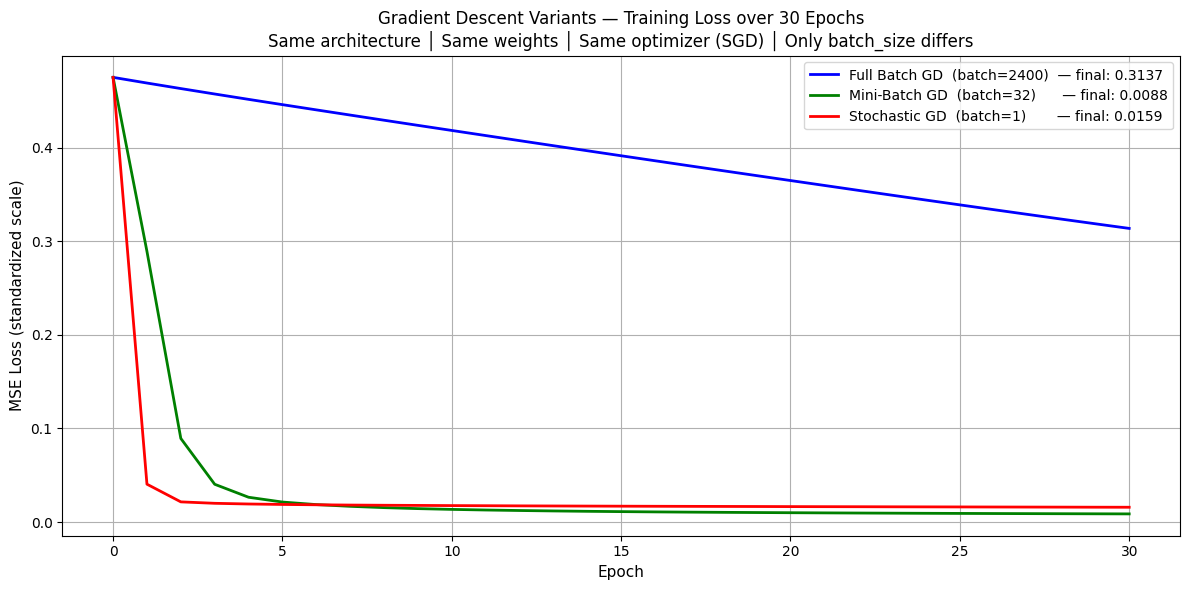

In [6]:
#################   VISUAL REPRESENTATION OF FULL-BATCH VS MINI-BATCH VS STOCHASTIC GRADIENT DESCENT   ######################
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from copy import deepcopy
import warnings
warnings.filterwarnings("ignore")       # suppress all convergence and other warnings

# ── Step 1: Create ONE model and initialize weights ───────────────────────────────
base_model = MLPRegressor(
    hidden_layer_sizes = (64, 128, 64, 32),
    activation         = "relu",
    solver             = "sgd",
    learning_rate_init = 0.01,
    momentum           = 0.0,
    max_iter           = 1,
    warm_start         = True,
    batch_size         = len(X_train),
    random_state       = 42,
    verbose            = False
)
base_model.fit(X_train, y_train.ravel())
initial_loss = base_model.loss_

# ── Step 2: Deepcopy base model into three separate models ────────────────────────
model_fullbatch  = deepcopy(base_model)
model_minibatch  = deepcopy(base_model)
model_stochastic = deepcopy(base_model)

model_minibatch.batch_size  = 32
model_stochastic.batch_size = 1

# ── Step 3: Train each model epoch by epoch and collect losses ────────────────────
EPOCHS = 30

def collect_losses(model, EPOCHS):
    losses = [initial_loss]
    for epoch in range(EPOCHS):
        model.fit(X_train, y_train.ravel())
        losses.append(model.loss_)
    return losses

losses_fullbatch  = collect_losses(model_fullbatch,  EPOCHS)
losses_minibatch  = collect_losses(model_minibatch,  EPOCHS)
losses_stochastic = collect_losses(model_stochastic, EPOCHS)

# Step 4: Plot 
plt.figure(figsize=(12, 6))

plt.plot(losses_fullbatch,
         label     = f"Full Batch GD  (batch={len(X_train)})  — final: {losses_fullbatch[-1]:.4f}",
         color     = "blue",
         linewidth = 2)

plt.plot(losses_minibatch,
         label     = f"Mini-Batch GD  (batch=32)      — final: {losses_minibatch[-1]:.4f}",
         color     = "green",
         linewidth = 2)

plt.plot(losses_stochastic,
         label     = f"Stochastic GD  (batch=1)       — final: {losses_stochastic[-1]:.4f}",
         color     = "red",
         linewidth = 2)

plt.title("Gradient Descent Variants — Training Loss over 30 Epochs\n"
          "Same architecture │ Same weights │ Same optimizer (SGD) │ Only batch_size differs",
          fontsize = 12)
plt.xlabel("Epoch",                         fontsize = 11)
plt.ylabel("MSE Loss (standardized scale)", fontsize = 11)
plt.legend(fontsize = 10)
plt.grid(True)
plt.tight_layout()
plt.show()

# Example 2 (Use PyTorch)

<h2 align="center"><div class="alert alert-success" style="margin: 20px"><b>PyTorch</b> is an open-source deep learning framework developed by Meta AI that gives you complete control over every step of building, training, and deploying neural networks, from research prototypes to production systems.</h2>

## Comparison: MLPRegressor vs PyTorch

| Category | Feature | MLPRegressor (scikit-learn) | PyTorch |
|---|---|---|---|
| ⚙️ **Hardware & Speed** | GPU acceleration | ❌ CPU only | ✅ NVIDIA CUDA, AMD ROCm, Apple MPS |
| | Training speed on large datasets | ❌ 10×–100× slower than GPU | ✅ GPU-accelerated — scales to billions of parameters |
| | Batch data loading | ❌ entire dataset loaded into RAM at once | ✅ DataLoader streams small batches — handles any dataset size |
| 🎮 **Control & Flexibility** | Training loop visibility | ❌ complete black box inside `.fit()` | ✅ every step explicit — forward pass, loss, backprop, update |
| | Custom logic between layers | ❌ impossible | ✅ insert any Python code anywhere in the forward pass |
| | Custom loss functions | ❌ fixed built-in options only | ✅ write any loss function in pure Python |
| | Choice of optimizers | ❌ SGD, Adam, L-BFGS only | ✅ SGD, Adam, AdamW, AdaGrad, RMSprop, and custom |
| 🏗️ **Architecture Support** | Architectures supported | ❌ simple fully-connected MLP only | ✅ MLP, CNN, RNN, LSTM, Transformer, GAN, Diffusion — anything |
| | Dropout & regularization | ❌ very limited (L2 penalty only) | ✅ Dropout, L1, L2, weight decay — fully configurable |
| | Batch / Layer normalization | ❌ not available | ✅ BatchNorm, LayerNorm, GroupNorm — all built-in |
| 🚀 **Production & Deployment** | Save / load model weights | ❌ Python pickle only — fragile | ✅ proper `.pt` checkpoints — weights, optimizer state, epoch |
| | Resume training mid-run | ❌ not possible | ✅ save checkpoint anytime, resume from exact same state |
| | Deploy to production | ❌ not suitable for real systems | ✅ TorchServe, ONNX export, TorchLite for mobile and edge |
| | Used in industry & research | ❌ prototyping and teaching only | ✅ OpenAI · Meta · Tesla · Stability AI · Google DeepMind |

>- <p style="color: purple;">PyTorch is powering the world's most important AI systems including OpenAI's GPT/DALL·E, DeepMind's Gemma, Meta's LLaMA, Stability AI's Stable Diffusion, and most models on Hugging Face.</p>


## What Stays the Same — What Changes
```
WHAT STAYS IDENTICAL:
  Architecture    : Input(5) → 64 → 128 → 64 → 32 → Output(1)
  Activation      : ReLU on every hidden layer
  Loss function   : Mean Squared Error (MSE)
  Dataset         : same X_train, y_train tensors
  Number of epochs: 30

WHAT CHANGES:Every step of training is now EXPLICIT and VISIBLE:
  MLPRegressor:                    PyTorch:
  ─────────────────                ───────────────────
  model.fit(X, y)         →        model.train()
                                   optimizer.zero_grad()
                                   pred = model(X)             ← forward pass
                                   loss = criterion(pred, y)   ← compute loss
                                   loss.backward()             ← backpropagation
                                   optimizer.step()            ← update weights
```
<p style="color: purple; padding-left: 320px;">These six lines are the <b>universal training loop</b> used in every PyTorch project in the world.</p>

In [7]:
##############################    DEFINE ENERGYNET ARCHITECTURE USING TORCH.NN         ###################################
# Define this once — all 4 optimizer experiments reuse this class by calling EnergyNet() to get a fresh model with random weights
################################################################################################################################

import torch          # core PyTorch library — tensors, autograd, math operations
import torch.nn as nn # nn = neural network module — layers, activations, loss functions
import rich

# STEP 1 — CONVERT NUMPY ARRAYS TO PYTORCH TENSORS
# torch.FloatTensor → creates a 32-bit float tensor (matches model weight precision)
X_train_t = torch.FloatTensor(X_train)   # training features  — shape (2400, 5)
y_train_t = torch.FloatTensor(y_train)   # training targets   — shape (2400, 1)
X_test_t  = torch.FloatTensor(X_test)    # test features      — shape (600,  5)
y_test_t  = torch.FloatTensor(y_test)    # test targets       — shape (600,  1)


# STEP 2 — DEFINE THE NEURAL NETWORK ARCHITECTURE
class EnergyNet(nn.Module):
    def __init__(self):
        super().__init__()  # calls nn.Module's own __init__() first. This is mandatory — it sets up PyTorch's internal bookkeeping. Without this line, model.parameters() would not work correctly.
        self.model = nn.Sequential(           # This is the simplest way to build a feedforward network in PyTorch. (a container that chains layers in order)
            nn.Linear(5,   64),  nn.ReLU(),   # Layer 1: 5  inputs  → 64  neurons  (5×64   + 64  = 384   params)
            nn.Linear(64, 128),  nn.ReLU(),   # Layer 2: 64 inputs  → 128 neurons  (64×128 + 128 = 8,320 params)
            nn.Linear(128, 64),  nn.ReLU(),   # Layer 3: 128 inputs → 64  neurons  (128×64 + 64  = 8,256 params)
            nn.Linear(64,  32),  nn.ReLU(),   # Layer 4: 64 inputs  → 32  neurons  (64×32  + 32  = 2,080 params)
            nn.Linear(32,   1)                # Output:  32 inputs  → 1   neuron   (32×1   + 1   = 33    params) NO activation function because this is regression — we want an unbounded continuous prediction, not a value squashed between 0 and 1
        )                                     # Total trainable parameters: 19,073

   # When you write `model(X_train_t)`, PyTorch automatically calls forward(X_train_t) to compute the prediction, builds the computation graph for backpropagation, and returns the output
    def forward(self, x):
        return self.model(x) 

### TRAIN WITH SGD + MOMENTUM
```
W_new = W_old − lr × v,       where v   = 0.9×v + 0.1×gradient
```

In [8]:
EPOCHS     = 30         
losses_sgd = []         

# Instantiate the model — this calls __init__() and builds all layers
model_sgd = EnergyNet()

optimizer_sgd = torch.optim.SGD(
    model_sgd.parameters(),  # all 19,073 learnable weights and biases updated after every backward pass
    lr       = 0.01,         # step size per weight update — SGD has no adaptive lr scaling so needs a larger lr (0.01) compared to Adam (0.001)
    momentum = 0.9           # retains 90% of previous velocity and adds 10% of current gradient
                             # momentum=0.0 → pure SGD — each update driven only by current gradient — slow and noisy
)

#print(model_sgd)
for epoch in range(EPOCHS):                       
    model_sgd.train()                             
    optimizer_sgd.zero_grad()                     
    pred = model_sgd(X_train_t)                # Forward pass
    loss = nn.MSELoss()(pred, y_train_t)       # Loss Calculation
    loss.backward()                            # Backward Propagation
    optimizer_sgd.step()                       # Weight Update
    losses_sgd.append(loss.item())             
    #print(f"  Epoch {epoch+1:>3}/{EPOCHS}  │  Loss: {loss.item():.5f}")  # For printing the loss value after every epoch


print(f"\n✅ SGD+Momentum training complete!  Final loss: {losses_sgd[-1]:.5f}")


✅ SGD+Momentum training complete!  Final loss: 0.51901


### TRAIN WITH ADAGRAD

```
W_new = W_old − lr × gradient / √(acc + ε),      where acc = acc + gradient²
```

In [9]:
EPOCHS     = 30          
losses_adagrad = []      

model_adagrad = EnergyNet()  

optimizer_adagrad = torch.optim.Adagrad(
    model_adagrad.parameters(),  # all 19,073 learnable weights and biases — each gets its OWN accumulated gradient sum
    lr = 0.01                    # initial lr before adaptive scaling kicks in — set larger than Adam/RMSprop because AdaGrad will shrink it automatically
)

#print(model_adagrad)
for epoch in range(EPOCHS):
    model_adagrad.train()                
    optimizer_adagrad.zero_grad()        
    pred = model_adagrad(X_train_t)      
    loss = nn.MSELoss()(pred, y_train_t)    
    loss.backward()    
    optimizer_adagrad.step()
    losses_adagrad.append(loss.item())       
   # print(f"  Epoch {epoch+1:>3}/{EPOCHS}  │  Loss: {loss.item():.5f}")

print(f"\n✅ AdaGrad training complete!  Final loss: {losses_adagrad[-1]:.5f}")


✅ AdaGrad training complete!  Final loss: 0.03451


### TRAIN WITH RMSPROP

```
W_new = W_old − lr × gradient / √(v + ε), where v  = 0.99×v + 0.01×gradient²　

```

In [10]:
EPOCHS     = 30          # number of complete passes through the entire training dataset (2400 samples)
losses_rms = []         # empty list to store loss after each epoch — used later to plot the RMSprop loss curve

model_rms = EnergyNet()  

optimizer_rms = torch.optim.RMSprop( 
    model_rms.parameters(),  
    lr    = 0.001,           
    alpha = 0.99             
)
#print(model_rms)
for epoch in range(EPOCHS):
    model_rms.train()      
    optimizer_rms.zero_grad()  
    pred = model_rms(X_train_t) 
    loss = nn.MSELoss()(pred, y_train_t)
    loss.backward()                     
    optimizer_rms.step()                
    losses_rms.append(loss.item())      
   # print(f"  Epoch {epoch+1:>3}/{EPOCHS}  │  Loss: {loss.item():.5f}")

print(f"\n✅ RMSprop training complete!  Final loss: {losses_rms[-1]:.5f}")


✅ RMSprop training complete!  Final loss: 0.03627


### TRAIN WITH ADAM
```
W_new = W_old − lr × m / √(v + ε),     where  m  = 0.9×m + 0.1×gradient,
                                              v  = 0.999×v + 0.001×gradient²　
```

In [11]:
EPOCHS     = 30    
losses_adam = []   

model_adam = EnergyNet()

optimizer_adam = torch.optim.Adam(
    model_adam.parameters(),
    lr    = 0.001,        # smaller lr than SGD — Adam's adaptive scaling handles the rest
    betas = (0.9, 0.999), # β1=0.9 controls direction memory, β2=0.999 controls magnitude memory
    eps   = 1e-8          # tiny value added to √v to prevent division by zero
)

#print(model_adam)
for epoch in range(EPOCHS):
    model_adam.train()
    optimizer_adam.zero_grad()
    pred = model_adam(X_train_t)
    loss = nn.MSELoss()(pred, y_train_t)
    loss.backward()
    optimizer_adam.step()              # applies full Adam update for all 19,073 weights:
                                       #   m = 0.9×m   + 0.1×grad        → update direction estimate
                                       #   v = 0.999×v + 0.001×grad²     → update magnitude estimate
                                       #   W = W − 0.001 × m / (√v + ε)  → adaptive weight update
    losses_adam.append(loss.item())
    #print(f"  Epoch {epoch+1:>3}/{EPOCHS}  │  Loss: {loss.item():.5f}")
print(f"\n✅ Adam training complete!  Final loss: {losses_adam[-1]:.5f}")


✅ Adam training complete!  Final loss: 0.11128


### Comparison

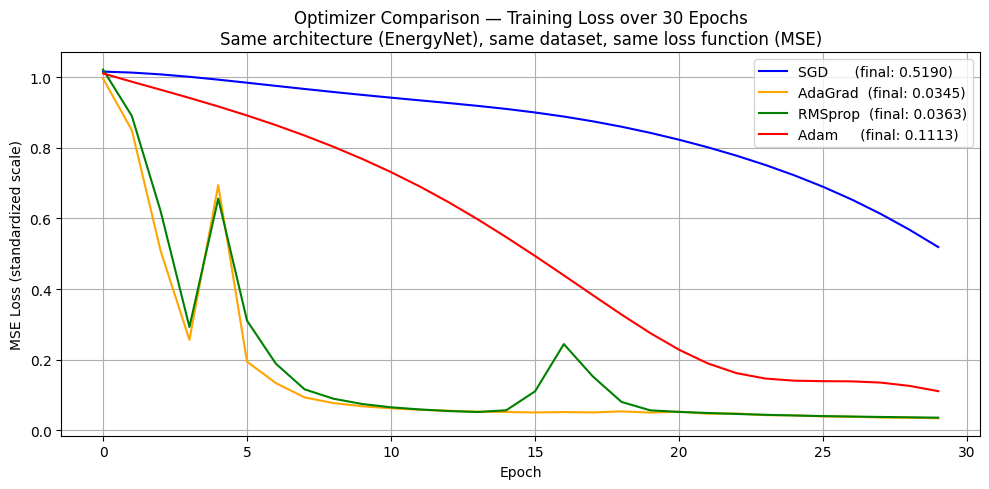

In [12]:
###############    PLOT ALL OPTIMIZERS — LOSS COMPARISON         #######################
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(losses_sgd,     label=f"SGD      (final: {losses_sgd[-1]:.4f})",     color="blue")
plt.plot(losses_adagrad, label=f"AdaGrad  (final: {losses_adagrad[-1]:.4f})", color="orange")
plt.plot(losses_rms,     label=f"RMSprop  (final: {losses_rms[-1]:.4f})",     color="green")
plt.plot(losses_adam,    label=f"Adam     (final: {losses_adam[-1]:.4f})",     color="red")

plt.title("Optimizer Comparison — Training Loss over 30 Epochs\n"
          "Same architecture (EnergyNet), same dataset, same loss function (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (standardized scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# <span style='background :lightgreen' >5. Example Questions to Check your Understanding about Training of a Feed Forward Neural Network</span>

## Question 1 — Forward Pass
- A small neural network has a single hidden neuron. Compute the output for each part using the given inputs, weights, bias, and activation function. For all parts, you can consider these inputs: **x₁ = 2.0, x₂ = 3.0**
    - **(a)** weights: w₁ = 0.5, w₂ = 0.4, bias = 1.0, activation = **ReLU**
    - **(b)** weights: w₁ = 0.5, w₂ = 0.4, bias = −5.0, activation = **ReLU**
    - **(c)** weights: w₁ = 0.3, w₂ = −0.8, bias = 0.5, activation = **Sigmoid** σ(z) = 1/(1+e⁻ᶻ), use use e¹·³ ≈ 3.669
    - **(d)** weights: w₁ = −1.0, w₂ = −1.0, bias = 2.5, activation = **tanh**, use use use tanh(−2.5) ≈ −0.987
    - **(e)** weights: w₁ = 0.6, w₂ = 0.2, bias = 0.0, activation = **None** (output neuron — regression)

<details>
<summary><b>💡 Click to reveal answer</b></summary>


```
FORMULA:   z = (x₁×w₁) + (x₂×w₂) + bias       a = activation(z)
           x₁ = 2.0,  x₂ = 3.0  for all parts

(a) ReLU — positive z:
    z = (2.0×0.5) + (3.0×0.4) + 1.0
      = 1.0 + 1.2 + 1.0
      = 3.2
    a = ReLU(3.2) = max(0, 3.2) = 3.2  ✅
    ReLU is ACTIVE — z is positive so output = z

(b) ReLU — negative z:
    z = (2.0×0.5) + (3.0×0.4) + (−5.0)
      = 1.0 + 1.2 − 5.0
      = −2.8
    a = ReLU(−2.8) = max(0, −2.8) = 0.0
    ReLU is INACTIVE — z is negative so output = 0
    This neuron contributes NOTHING to the next layer

(c) Sigmoid:
    z = (2.0×0.3) + (3.0×−0.8) + 0.5
      = 0.6 − 2.4 + 0.5
      = −1.3
    e⁻⁽⁻¹·³⁾ = e¹·³ ≈ 3.669
    a = σ(−1.3) = 1 / (1 + e¹·³)
                = 1 / (1 + 3.669)
                = 1 / 4.669
                = 0.214
    Output is between 0 and 1 — as expected for Sigmoid

(d) tanh:
    z = (2.0×−1.0) + (3.0×−1.0) + 2.5
      = −2.0 − 3.0 + 2.5
      = −2.5
    a = tanh(−2.5) ≈ −0.987
    

(e) No activation (regression output neuron):
    z = (2.0×0.6) + (3.0×0.2) + 0.0
      = 1.2 + 0.6 + 0.0
      = 1.8
    a = z = 1.8
    No activation applied — raw z is the final prediction
    Output is unbounded — can be any value (−∞ to +∞)
```
</details>


## Question 2 — Loss Calculation
- **(a)** A regression model predicts energy consumption for 4 houses. Compute the MAE and MSE loss:
```
| Sample | Predicted (ŷ) | Actual (y) |
|--------|--------------|------------|
| 1      | 210          | 200        |
| 2      | 185          | 190        |
| 3      | 305          | 300        |
| 4      | 95           | 100        |
```

- **(b)** The following table show the outputs of a spam classifier for 3 emails. Compute BCE loss for each sample. Use: log(0.9)=−0.105, log(0.8)=−0.223, log(0.4)=−0.916, log(0.6)=−0.511
```
| Sample | True Label (y) | Predicted Prob (p) |
|--------|---------------|-------------------|
| 1      | 1 (spam)      | 0.9               |
| 2      | 0 (not spam)  | 0.2               |
| 3      | 1 (spam)      | 0.4               |
```


- **(c)** A model classifies an image into 3 classes: cat, dog, bird. True label is **cat**. Predicted probabilities after Softmax: p_cat=0.7, p_dog=0.2, p_bird=0.1. Compute the CCE loss. Use log(0.7)=−0.357

<details>
<summary><b>💡 Click to reveal answer</b></summary>

```
(a) MSE:
    errors       = [210−200, 185−190, 305−300, 95−100]
                 = [10, −5, 5, −5]
    errors²      = [100, 25, 25, 25]
    MSE          = mean(100, 25, 25, 25)
                 = 175 / 4
                 = 43.75  ✅

    MAE:
    |errors|     = [|10|, |−5|, |5|, |−5|]
                 = [10, 5, 5, 5]
    MAE          = mean(10, 5, 5, 5)
                 = 25 / 4
                 = 6.25 
    Notice MAE (6.25) < MSE (43.75) — MSE penalises
    larger errors more heavily due to squaring

(b) Binary Cross-Entropy:
    Formula: −[ y·log(p) + (1−y)·log(1−p) ]

    Sample 1 (y=1, p=0.9):
      = −[ y×log(p) + (1−y)×log(1−p) ]
      = −[ 1×log(0.9) + (1-1)×log(1-0.9) ]
      = −[ 1×(-0.105) + 0) ]
      = 0.105  (low loss — model was confident and correct)

    Sample 2 (y=0, p=0.2):
      = −[ y×log(p) + (1−y)×log(1−p) ]
      = −[ 0×log(0.2) + (1−0)×log(1−0.2) ]
      = −[ 0×log(0.2) + 1×log(0.8) ]
      = 0.223  (low loss — model correctly predicted not spam)

    Sample 3 (y=1, p=0.4):
      = −[ 1×log(0.4) + 0×log(0.6) ]
      = −[ 1×(−0.916) + 0 ]
      = 0.916   (high loss — model was uncertain but label was spam)

    Key insight: Sample 3 has much higher loss because
    the model assigned only 40% probability to the correct class

(c) Categorical Cross-Entropy:
    Formula: −Σ yᵢ · log(pᵢ)
    True label = cat  →  y_cat=1, y_dog=0, y_bird=0

    loss = −[ 1×log(0.7) + 0×log(0.2) + 0×log(0.1) ]
         = −[ 1×(−0.357) + 0 + 0 ]
         = 0.357  ✅

    Key insight: since y=0 for all wrong classes they
    disappear from the sum — CCE always reduces to
    −log(probability assigned to the correct class)
    Lower probability for correct class = higher loss
```
</details>


## Question 3 — Backward Propagation
- Consider the following minimal neural network with **one input neuron, one hidden neuron, and one output neuron**. There are no bias terms to keep the calculations simple.
    - w₁ = 0.5  (weight connecting input to hidden neuron)
    - w₂ = 0.3  (weight connecting hidden neuron to output neuron)
    - Ground truth value:  y    = 1.0
    - Loss function:  MSE  = (ŷ − y)²     ← no mean needed for one sample
**Architecture:**
```
                    HIDDEN LAYER              OUTPUT LAYER
                   ┌─────────────┐           ┌─────────────┐
                   │             │           │             │
  INPUT            │  z₁ = x×w₁  │           │  ŷ = a₁×w₂  │
  ──────           │             │           │             │
  x = 2.0  ──w₁──→ │  a₁=ReLU(z₁)│──── w₂ ──→│  (no        │──→  ŷ  (prediction)
                   │             │           │  activation)│
                   └─────────────┘           └─────────────┘
```
**Forward Pass (left to right):**
```  

Full data flow (left to right — Forward Pass):
  ┌────────┐      ┌──────────────┐     ┌────────────────┐     ┌──────────────┐     ┌──────────┐
  │ x = 2.0│─ w₁ →│ z₁ = x × w₁  │─────│ a₁ = ReLU(z₁)  │─ w₂→│ ŷ = a₁ × w₂  │────→│   Loss   │
  └────────┘      └──────────────┘     └────────────────┘     └──────────────┘     └──────────┘
```
**Backward Pass (Gradient flow from right to left):**
```
  ┌─────────┐      ┌──────────────┐     ┌────────────────┐     ┌──────────────┐     ┌──────────┐
  │∂Loss/∂w₁│←──── │ ∂z₁/∂w₁ = x  │←────│ ∂a₁/∂z₁ (ReLU) │←────│ ∂ŷ/∂a₁ = w₂  │←────│∂Loss/∂ŷ  │
  └─────────┘      └──────────────┘     └────────────────┘     └──────────────┘     └──────────┘
```
**Keeping above in mind, answer the following questions:**
- **(a)** Perform the full **Forward Pass** — compute z₁, a₁, ŷ, and Loss step by step.
- **(b)** Compute **∂Loss/∂w₂** — the gradient of the loss with respect to w₂. Note that w₂ directly connects to the output so only **2 chain rule steps** are needed:
```
∂Loss/∂w₂  =  ∂Loss/∂ŷ  ×  ∂ŷ/∂w₂
```
- **(c)** Compute **∂Loss/∂w₁** — the gradient of the loss with respect to w₁. Note that w₁ is further from the output so the gradient must travel through **4 chain rule steps** all the way back to w₁:
```
∂Loss/∂w₁  =  ∂Loss/∂ŷ  ×  ∂ŷ/∂a₁  ×  ∂a₁/∂z₁  ×  ∂z₁/∂w₁
```
- **(d)** Both gradients are negative. What does a **negative gradient** tell the optimizer to do to each weight? Which weight has a **stronger influence** on the loss and why?

<details>
<summary><b>💡 Click to reveal answer</b></summary>

```
(a) Forward Pass — left to right:

    z₁   = x × w₁          = 2.0 × 0.5            =  1.0
    a₁   = ReLU(z₁)         = ReLU(1.0)             =  1.0   (z₁ > 0 → ReLU is ACTIVE → passes value through)
    ŷ    = a₁ × w₂          = 1.0 × 0.3            =  0.3
    Loss = (ŷ − y)²         = (0.3 − 1.0)²         =  (−0.7)²  =  0.49

    Interpretation: model predicted 0.3 but true value is 1.0
    → prediction is too LOW → weights need to INCREASE


(b) ∂Loss/∂w₂ — w₂ is only 2 steps away from Loss:

    Step 1 — how does Loss change when ŷ changes?
      ∂Loss/∂ŷ  = 2 × (ŷ − y)  =  2 × (0.3 − 1.0)  =  −1.4

    Step 2 — how does ŷ change when w₂ changes?
      ŷ = a₁ × w₂
      ∂ŷ/∂w₂  =  a₁  =  1.0

    Chain rule:
      ∂Loss/∂w₂  =  ∂Loss/∂ŷ  ×  ∂ŷ/∂w₂
                 =  −1.4  ×  1.0
                 =  −1.4  ✅


(c) ∂Loss/∂w₁ — w₁ is 4 steps away from Loss — gradient must
    travel through ŷ → a₁ → z₁ → w₁:

    Step 1 — ∂Loss/∂ŷ  = −1.4             (already computed in part b)

    Step 2 — how does ŷ change when a₁ changes?
      ŷ = a₁ × w₂
      ∂ŷ/∂a₁  =  w₂  =  0.3

    Step 3 — how does a₁ change when z₁ changes?
      a₁ = ReLU(z₁)
      ∂a₁/∂z₁  =  1.0    (ReLU derivative = 1 when z₁ > 0)
                           (ReLU derivative = 0 when z₁ < 0 — dead neuron)

    Step 4 — how does z₁ change when w₁ changes?
      z₁ = x × w₁
      ∂z₁/∂w₁  =  x  =  2.0

    Chain rule — multiply all 4 steps:
      ∂Loss/∂w₁  =  ∂Loss/∂ŷ  ×  ∂ŷ/∂a₁  ×  ∂a₁/∂z₁  ×  ∂z₁/∂w₁
                 =  −1.4  ×  0.3  ×  1.0  ×  2.0
                 =  −0.84  ✅


(d) Sign and Magnitude analysis:

    ∂Loss/∂w₂ = −1.4   (negative)
      → increasing w₂ would DECREASE the loss
      → optimizer should INCREASE w₂
      → w₂_new = 0.3 − 0.01×(−1.4) = 0.3 + 0.014 = 0.314   (lr=0.01)

    ∂Loss/∂w₁ = −0.84  (negative)
      → increasing w₁ would also DECREASE the loss
      → optimizer should INCREASE w₁
      → w₁_new = 0.5 − 0.01×(−0.84) = 0.5 + 0.0084 = 0.5084 (lr=0.01)

    Magnitude comparison:
      |∂Loss/∂w₂| = 1.4    ← STRONGER influence on loss
      |∂Loss/∂w₁| = 0.84   ← weaker influence on loss

      w₂ has stronger influence because it sits directly between
      the last hidden neuron and the output — any change to w₂
      immediately and fully affects ŷ and therefore the loss.
      w₁ sits further away — its influence on the loss is diluted
      by multiplying through w₂ = 0.3 in the chain rule,
      which reduces the gradient magnitude from 1.4 down to 0.84.
```
</details>

## Question 4 — Weight Update
- A weight currently has value **W = 0.5** and its gradient is **∂Loss/∂W = −0.4**. Use **learning rate lr = 0.1** for all parts.
    - **(a) SGD (plain):**  Compute W_new
    - **(b) SGD + Momentum:**  Previous velocity v = 0.2. Compute new v then W_new
    - **(c) AdaGrad:**  Previous accumulated sum acc = 0.5. Compute new acc then W_new. Use √0.67 ≈ 0.819, ε = 0.01
    - **(d) RMSprop:**  Previous moving average v = 0.3. Compute new v then W_new. Use   √0.3086 ≈ 0.556, ε = 0.01
    - **(e) Adam:**  Previous m = 0.1, previous v = 0.2. Compute new m, new v, then W_new. Use √0.2100 ≈ 0.458, ε = 0.01

<details>
<summary><b>💡 Click to reveal answer</b></summary>

```
Given:  W = 0.5,  gradient = −0.4,  lr = 0.1

(a) SGD (plain):
    W_new = W − lr × gradient
          = 0.5 − 0.1 × (−0.4)
          = 0.5 + 0.04
          = 0.54 
    Gradient is negative → weight INCREASES

(b) SGD + Momentum  (v_old = 0.2):
    v_new = 0.9 × v_old  +  0.1 × gradient
          = 0.9 × 0.2    +  0.1 × (−0.4)
          = 0.18 − 0.04
          = 0.14
    W_new = W − lr × v_new
          = 0.5 − 0.1 × 0.14
          = 0.5 − 0.014
          = 0.486 
    Notice: momentum SLOWS DOWN the update compared to plain SGD
    because previous velocity (0.2) was positive — pulling
    against the current negative gradient

(c) AdaGrad  (acc_old = 0.5):
    acc_new = acc_old + gradient²
            = 0.5 + (−0.4)²
            = 0.5 + 0.16
            = 0.66
    W_new = W − lr × gradient / √(acc_new + ε)
          = 0.5 − 0.1 × (−0.4) / √(0.66 + 0.01)
          = 0.5 − 0.1 × (−0.4) / √0.67
          = 0.5 − 0.1 × (−0.4) / 0.819
          = 0.5 + 0.04884
          = 0.549  
    Effective lr = 0.1/0.812 = 0.123 — slightly scaled down
    As acc grows over time, effective lr shrinks further

(d) RMSprop  (v_old = 0.3):
    v_new = 0.99 × v_old  +  0.01 × gradient²
          = 0.99 × 0.3    +  0.01 × (−0.4)²
          = 0.297 + 0.01 × 0.16
          = 0.297 + 0.0016
          = 0.2986
    W_new = W − lr × gradient / √(v_new + ε)
          = 0.5 − 0.1 × (−0.4) / √(0.2986 + 0.01)
          = 0.5 − 0.1 × (−0.4) / √0.3086
          = 0.5 + 0.04 / 0.556
          = 0.5 + 0.072
          = 0.572 
    v changes very slowly (0.3 → 0.2986) due to 0.99 decay
    keeping learning rate stable — unlike AdaGrad which
    keeps growing acc and eventually stops learning

(e) Adam  (m_old = 0.1,  v_old = 0.2):
    m_new = 0.9 × m_old   +  0.1 × gradient
          = 0.9 × 0.1     +  0.1 × (−0.4)
          = 0.09 − 0.04
          = 0.05

    v_new = 0.999 × v_old  +  0.001 × gradient²
          = 0.999 × 0.2    +  0.001 × (−0.4)²
          = 0.1998 + 0.001 × 0.16
          = 0.1998 + 0.00016
          = 0.2000

    W_new = W − lr × m_new / √(v_new + ε)
          = 0.5 − 0.1 × 0.05 / √(0.2000 + 0.01)
          = 0.5 − 0.005 / √0.2100
          = 0.5 − 0.005 / 0.458
          = 0.5 − 0.0109
          = 0.489  
    m smooths the gradient direction (0.1 → 0.05)
    v barely changes (0.2 → 0.2000) — very stable magnitude estimate
    Adam produces a cautious, well-scaled update

─────────────────────────────────────────────────────────
Final Comparison (W_old = 0.5, gradient = −0.4):

  SGD Plain      →  W_new = 0.540   largest raw update
  SGD+Momentum   →  W_new = 0.486   slowed by opposing past velocity
  AdaGrad        →  W_new = 0.549   slightly larger than SGD
  RMSprop        →  W_new = 0.572   larger step — stable lr scaling
  Adam           →  W_new = 0.489   smallest, most cautious update
─────────────────────────────────────────────────────────
```